# Ames Housing Prices EDA 

In [55]:
#import libraries and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
#read and display first five rows of dataset
df = pd.read_csv("/Users/haarism/Projects/housing-price-project/Data/train.csv")
df.head(5)

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,534,531363010,20,RL,80.0,9605,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,159000
1,803,906203120,20,RL,90.0,14684,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,6,2009,WD,Normal,271900
2,956,916176030,20,RL,NaN,14375,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,1,2009,COD,Abnorml,137500
3,460,528180130,120,RL,48.0,6472,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,248500
4,487,528290030,80,RL,61.0,9734,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,167000


In [57]:
#display dataset shape
df.shape

(2197, 82)

In [58]:
#display the column names of the dataset
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [59]:
#displaying columns and their datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2197 entries, 0 to 2196
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2197 non-null   int64  
 1   PID              2197 non-null   int64  
 2   MS SubClass      2197 non-null   int64  
 3   MS Zoning        2197 non-null   object 
 4   Lot Frontage     1835 non-null   float64
 5   Lot Area         2197 non-null   int64  
 6   Street           2197 non-null   object 
 7   Alley            143 non-null    object 
 8   Lot Shape        2197 non-null   object 
 9   Land Contour     2197 non-null   object 
 10  Utilities        2197 non-null   object 
 11  Lot Config       2197 non-null   object 
 12  Land Slope       2197 non-null   object 
 13  Neighborhood     2197 non-null   object 
 14  Condition 1      2197 non-null   object 
 15  Condition 2      2197 non-null   object 
 16  Bldg Type        2197 non-null   object 
 17  House Style   

In [60]:
#display descriptive statistics
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2197.000000,2.197000e+03,2197.000000,1835.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2175.000000,...,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000,2197.000000
mean,1460.512517,7.127872e+08,57.064178,69.549319,10268.070096,6.116523,5.552572,1972.030951,1984.781065,105.101609,...,92.436959,48.768320,22.393719,2.361402,15.954028,2.789713,57.404188,6.189804,2007.793810,182376.851161
std,846.537251,1.887751e+08,42.360690,23.188224,7975.740885,1.429613,1.107019,30.450069,20.898245,184.897165,...,121.422842,69.127588,62.063281,22.843004,56.495484,39.991010,639.103790,2.746902,1.314345,81168.157405
min,1.000000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,13100.000000
25%,733.000000,5.284410e+08,20.000000,58.500000,7500.000000,5.000000,5.000000,1954.000000,1966.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,130000.000000
50%,1452.000000,5.354532e+08,50.000000,69.000000,9488.000000,6.000000,5.000000,1975.000000,1994.000000,0.000000,...,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163500.000000
75%,2196.000000,9.071811e+08,70.000000,80.000000,11660.000000,7.000000,6.000000,2002.000000,2004.000000,166.000000,...,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,215000.000000
max,2929.000000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,870.000000,742.000000,584.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [61]:
#displaying unique values in each categorical columns
categorical_cols = df.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

MS Zoning: 7 unique values
Street: 2 unique values
Alley: 2 unique values
Lot Shape: 4 unique values
Land Contour: 4 unique values
Utilities: 3 unique values
Lot Config: 5 unique values
Land Slope: 3 unique values
Neighborhood: 28 unique values
Condition 1: 9 unique values
Condition 2: 8 unique values
Bldg Type: 5 unique values
House Style: 8 unique values
Roof Style: 6 unique values
Roof Matl: 8 unique values
Exterior 1st: 16 unique values
Exterior 2nd: 17 unique values
Mas Vnr Type: 4 unique values
Exter Qual: 4 unique values
Exter Cond: 5 unique values
Foundation: 6 unique values
Bsmt Qual: 5 unique values
Bsmt Cond: 5 unique values
Bsmt Exposure: 4 unique values
BsmtFin Type 1: 6 unique values
BsmtFin Type 2: 6 unique values
Heating: 6 unique values
Heating QC: 5 unique values
Central Air: 2 unique values
Electrical: 5 unique values
Kitchen Qual: 5 unique values
Functional: 8 unique values
Fireplace Qu: 5 unique values
Garage Type: 6 unique values
Garage Finish: 3 unique values
Gar

In [62]:
#finding missing values in dataset
missing = pd.DataFrame(df.isnull().sum().sort_values(ascending=False))
missing.columns = ['Count']
missing['Percentage'] = missing['Count']/len(df) * 100
missing = missing[missing.Count > 0]
#display the count and percentage of columns which contain missing values 
print(missing)
#for now we can understand the dataset more from missing values, data cleaning will come after

                Count  Percentage
Pool QC          2185   99.453801
Misc Feature     2117   96.358671
Alley            2054   93.491124
Fence            1778   80.928539
Mas Vnr Type     1329   60.491579
Fireplace Qu     1066   48.520710
Lot Frontage      362   16.477014
Garage Yr Blt     122    5.553027
Garage Qual       122    5.553027
Garage Cond       122    5.553027
Garage Finish     122    5.553027
Garage Type       120    5.461994
Bsmt Exposure      69    3.140646
BsmtFin Type 2     68    3.095130
BsmtFin Type 1     67    3.049613
Bsmt Cond          67    3.049613
Bsmt Qual          67    3.049613
Mas Vnr Area       22    1.001365
Bsmt Full Bath      1    0.045517
BsmtFin SF 2        1    0.045517
Bsmt Unf SF         1    0.045517
Total Bsmt SF       1    0.045517
Electrical          1    0.045517
BsmtFin SF 1        1    0.045517
Bsmt Half Bath      1    0.045517
Garage Cars         1    0.045517
Garage Area         1    0.045517


**Interpretation:**
 
Several features have missing values consisting of over 90% of the data, this includes Pool QC, Misc Feature, and Alley, followed by 80% from Fence. These high percentages suggest majority of these houses do not consist of these fearures, for example Pool Qc, showing absence of pools rather than incomplete data. 

Other features like Fireplace Qu has almost half of its data as missing values. Lot Frontage has 16% of missing values with the rest of the features containing missing values below 6%. These features are can be seen majority of the houses with an absense within few houses. 

Later during data cleaning, the features with high missing percentages (above 80%) are likely to be removed, features with moderate percentages (>40%) may require imputation (using mode or mean). 

## Date Visualization

Text(0.5, 1.0, 'Missing Values Heatmap')

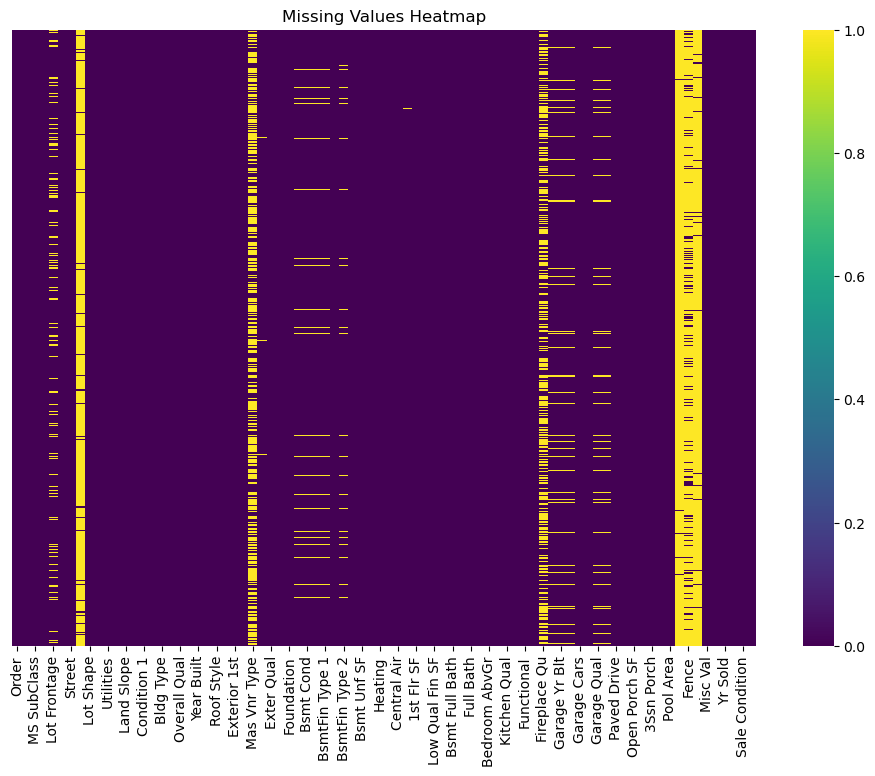

In [71]:
#Heatmap provising overall idea on missing values
plt.figure(figsize=(12, 8))  
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")

array([[<Axes: title={'center': 'Order'}>,
        <Axes: title={'center': 'PID'}>,
        <Axes: title={'center': 'MS SubClass'}>,
        <Axes: title={'center': 'Lot Frontage'}>,
        <Axes: title={'center': 'Lot Area'}>,
        <Axes: title={'center': 'Overall Qual'}>],
       [<Axes: title={'center': 'Overall Cond'}>,
        <Axes: title={'center': 'Year Built'}>,
        <Axes: title={'center': 'Year Remod/Add'}>,
        <Axes: title={'center': 'Mas Vnr Area'}>,
        <Axes: title={'center': 'BsmtFin SF 1'}>,
        <Axes: title={'center': 'BsmtFin SF 2'}>],
       [<Axes: title={'center': 'Bsmt Unf SF'}>,
        <Axes: title={'center': 'Total Bsmt SF'}>,
        <Axes: title={'center': '1st Flr SF'}>,
        <Axes: title={'center': '2nd Flr SF'}>,
        <Axes: title={'center': 'Low Qual Fin SF'}>,
        <Axes: title={'center': 'Gr Liv Area'}>],
       [<Axes: title={'center': 'Bsmt Full Bath'}>,
        <Axes: title={'center': 'Bsmt Half Bath'}>,
        <Axes: t

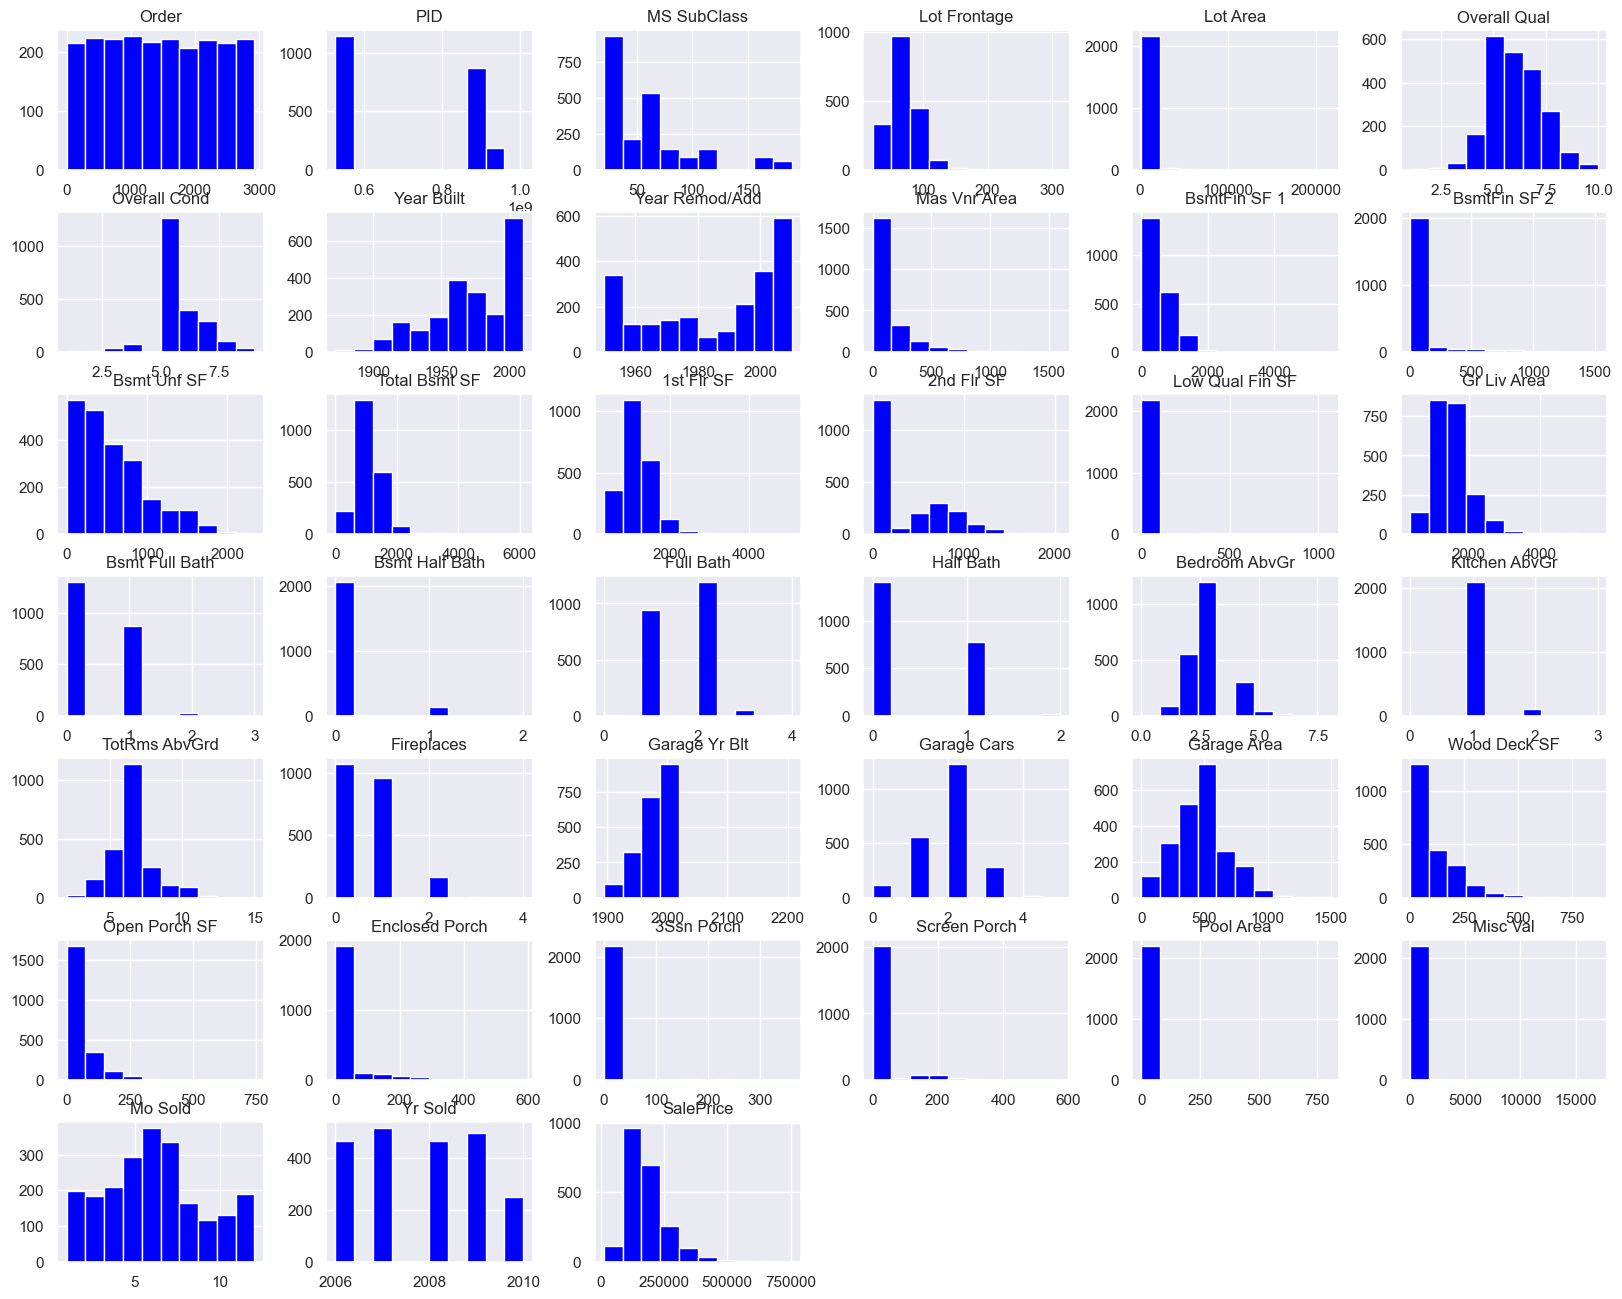

In [73]:
#Data distribution 
sns.set(rc={"figure.figsize": (20,16)})
df.hist(color="blue")

## Final Summary